**Import Libraries**

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

**Load Dataset**

In [35]:
df = pd.read_csv("full_grouped.csv")

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Display first five rows
df.head()

/tmp/ipykernel_2311/2081821545.py:4: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"])


,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region
0,2020-01-22,Afghanistan,0,0,0,0,0,0,0,Eastern Mediterranean
1,2020-01-22,Albania,0,0,0,0,0,0,0,Europe
2,2020-01-22,Algeria,0,0,0,0,0,0,0,Africa
3,2020-01-22,Andorra,0,0,0,0,0,0,0,Europe
4,2020-01-22,Angola,0,0,0,0,0,0,0,Africa


**Dataset Information**

In [36]:
df.info()

# Dataset Shape
print("Rows and Columns:", df.shape)

# Statistical Summary
df.describe()

# Missing Values
print(df.isnull().sum())

# Duplicate Rows
print("Duplicate Rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35156 entries, 0 to 35155
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            35156 non-null  datetime64[ns]
 1   Country/Region  35156 non-null  object        
 2   Confirmed       35156 non-null  int64         
 3   Deaths          35156 non-null  int64         
 4   Recovered       35156 non-null  int64         
 5   Active          35156 non-null  int64         
 6   New cases       35156 non-null  int64         
 7   New deaths      35156 non-null  int64         
 8   New recovered   35156 non-null  int64         
 9   WHO Region      35156 non-null  object        
dtypes: datetime64[ns](1), int64(7), object(2)
memory usage: 2.7+ MB
Rows and Columns: (35156, 10)
Date              0
Country/Region    0
Confirmed         0
Deaths            0
Recovered         0
Active            0
New cases         0
New deaths        0
New reco

** Basic Dataset Insights**

In [37]:
# Basic Dataset Insights
print("Total Countries:", df["Country/Region"].nunique())

print("Date Range:")
print(df["Date"].min())
print(df["Date"].max())

print("Highest Confirmed Cases:", df["Confirmed"].max())

print("Highest Deaths:", df["Deaths"].max())

Total Countries: 187
Date Range:
2020-01-22 00:00:00
2020-07-27 00:00:00
Highest Confirmed Cases: 4290259
Highest Deaths: 148011


**Task 1: Line Plot (Cases vs Date)**

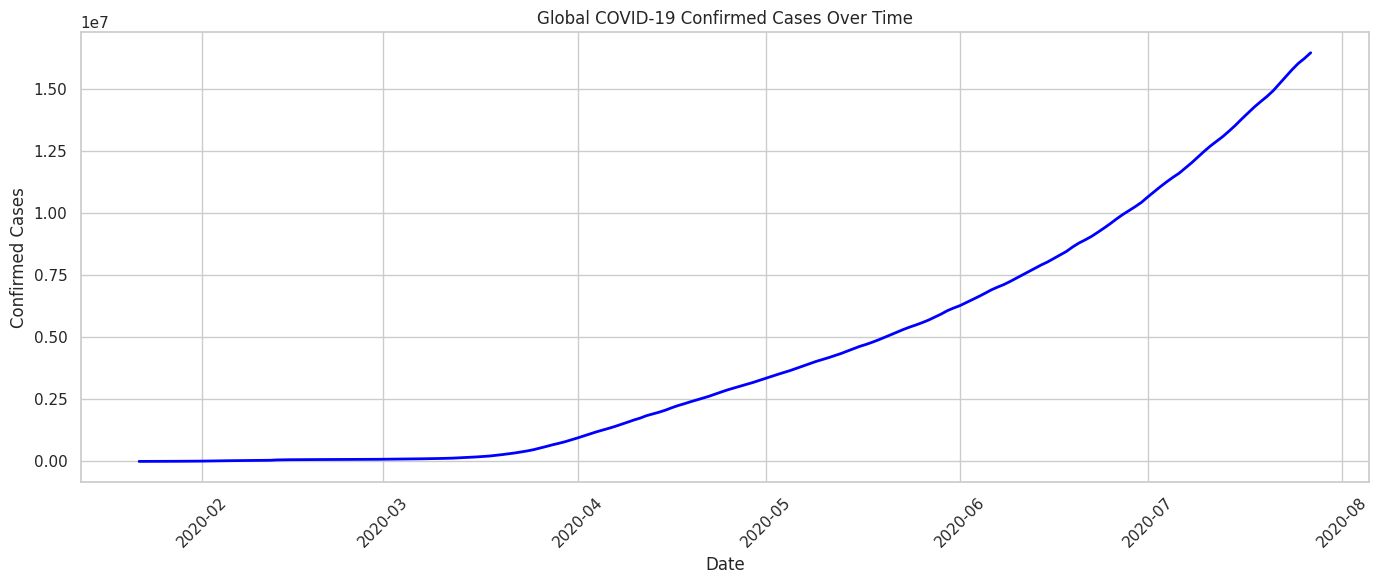

In [38]:
# Group data by date and calculate total confirmed cases
trend = df.groupby("Date")["Confirmed"].sum().reset_index()

plt.figure(figsize=(14,6))

plt.plot(
    trend["Date"],
    trend["Confirmed"],
    color="blue",
    linewidth=2
)

plt.title("Global COVID-19 Confirmed Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Observations
*   Global COVID-19 confirmed cases increased steadily over time.
*   A sharp rise in cases is observed after the early months of the pandemic.
*   The graph shows an overall upward trend in cumulative confirmed cases.

**Task 2: Compare Top 5 Countries**

/tmp/ipykernel_2311/2942259465.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


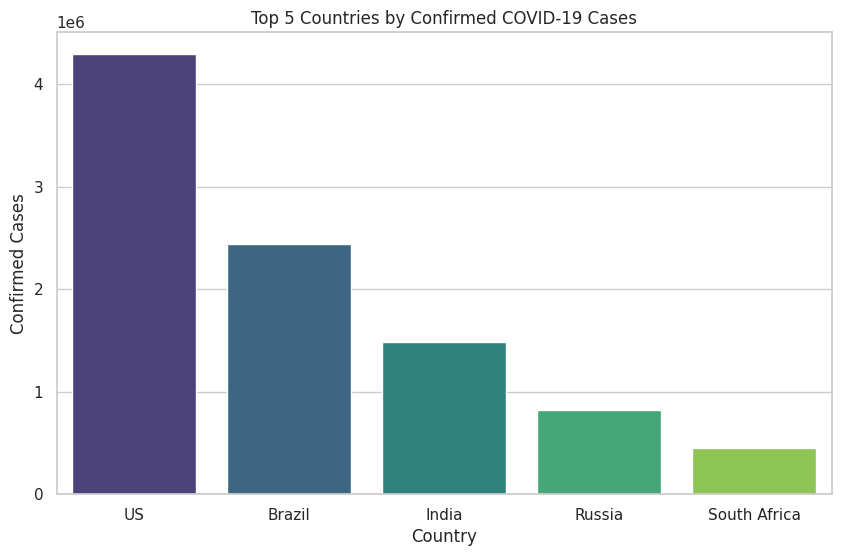

In [39]:
# Get latest available date
latest_date = df["Date"].max()

# Filter latest data
latest = df[df["Date"] == latest_date]

# Select top 5 countries
top5 = latest.sort_values(
    by="Confirmed",
    ascending=False
).head(5)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Country/Region",
    y="Confirmed",
    data=top5,
    palette="viridis"
)

plt.title("Top 5 Countries by Confirmed COVID-19 Cases")
plt.xlabel("Country")
plt.ylabel("Confirmed Cases")

plt.show()

Observations
*   The United States has the highest number of confirmed cases.
*   Brazil and India also report very high case counts.
*   The top five countries contribute a significant portion of global cases.

**Task 3: Correlation Heatmap**

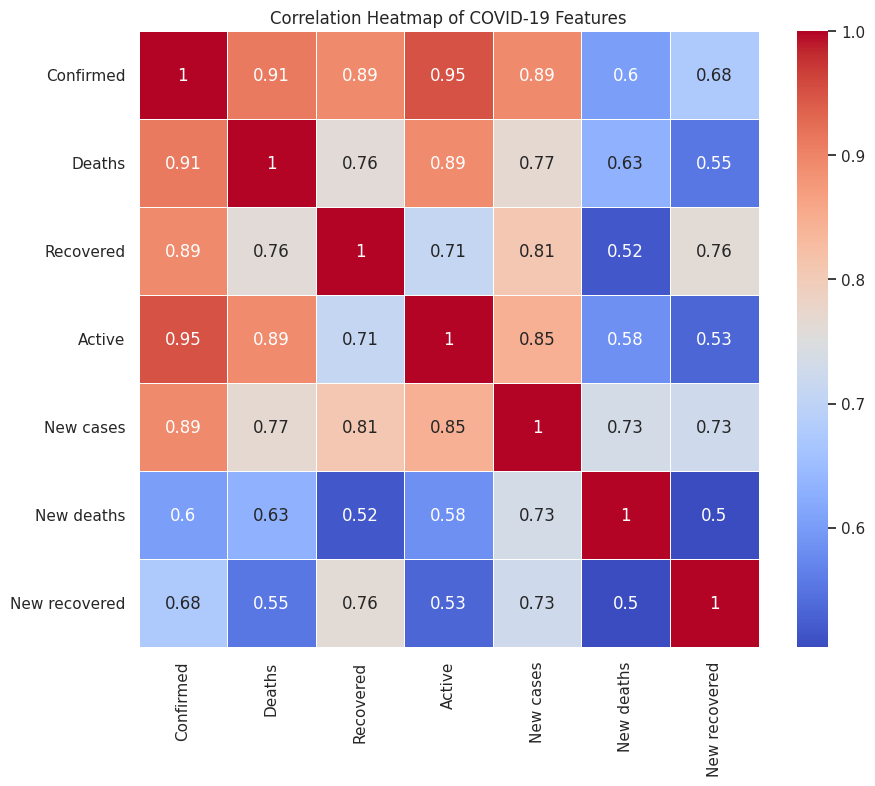

In [40]:
# Select numerical columns
correlation = df[
    [
        "Confirmed",
        "Deaths",
        "Recovered",
        "Active",
        "New cases",
        "New deaths",
        "New recovered"
    ]
].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of COVID-19 Features")

plt.show()

Observations
*   Confirmed cases have a strong positive correlation with deaths.
*   Recovered cases are also highly correlated with confirmed cases.
*   Active cases show a moderate correlation with new cases.

**Task 4: Scatter Plot**

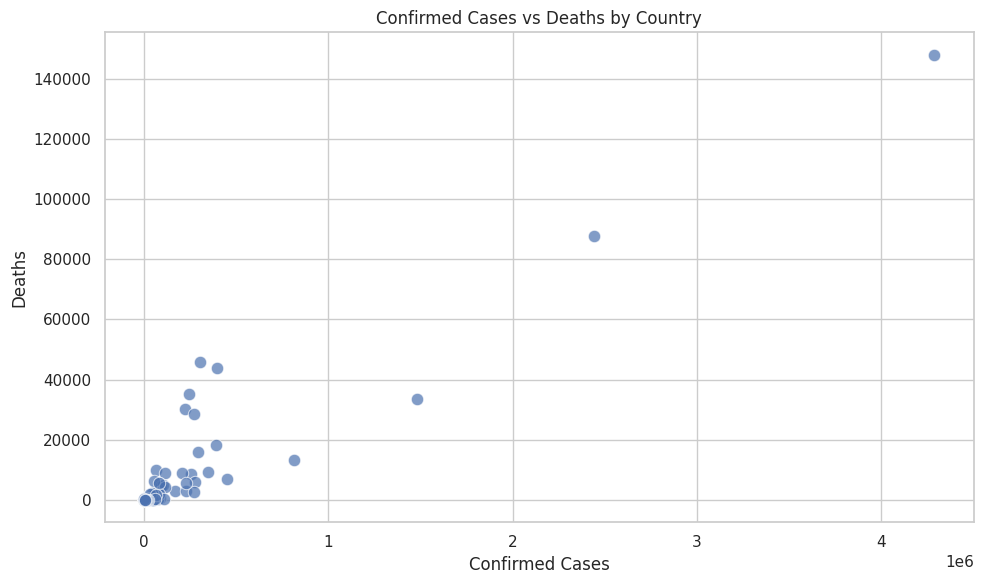

In [32]:
# Get the latest date available in the dataset
latest_date = df["Date"].max()

# Filter data for only the latest date
latest = df[df["Date"] == latest_date]

# Create the scatter plot
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=latest,
    x="Confirmed",
    y="Deaths",
    s=80,          # Marker size
    alpha=0.7      # Transparency
)

plt.title("Confirmed Cases vs Deaths by Country")
plt.xlabel("Confirmed Cases")
plt.ylabel("Deaths")
plt.grid(True)

plt.tight_layout()
plt.show()

Observations
*   Countries with higher confirmed cases generally report higher deaths.
*   Most countries are clustered near lower values.
*   LA few countries appear as outliers with extremely high confirmed cases and deaths.

**Conclusion:**

The Exploratory Data Analysis (EDA) of the COVID-19 dataset revealed a continuous increase in confirmed cases over time. The comparison of the top five countries showed that a few countries contributed significantly to the global case count. The correlation heatmap indicated a strong positive relationship between confirmed cases, deaths, and recoveries. The scatter plot further demonstrated that countries with more confirmed cases generally experienced higher numbers of deaths. Overall, the visualizations provide meaningful insights into the global spread and impact of COVID-19.